<a href="https://colab.research.google.com/github/George1902/Challenge_TelecomX_Machine_Learning/blob/main/Challenge_Telecom_X_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge Telecom X Análisis Predicción de Cancelación (Churn)

## 💡Acerca del desafío 💡

Telecom X – Parte 2: Predicción de Cancelación (Churn)

📣 Historia del Desafío

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!

🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

🧠 Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

🧰 Lo que vas a practicar

✅ Preprocesamiento de datos para Machine Learning
✅ Construcción y evaluación de modelos predictivos
✅ Interpretación de resultados y entrega de insights
✅ Comunicación técnica con enfoque estratégico

🚀 Ahora eres: Analista Junior de Machine Learning

Telecom X confía en tu entrega para dar los próximos pasos hacia una solución de inteligencia predictiva eficaz. ¡Buena suerte!

## Extracción del Archivo Tratado

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [1]:
import pandas as pd

In [2]:
datos_clientes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/telecom_x_preprocesado.csv')

In [3]:
datos_clientes

,customerID,Churn_Original,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,Meses_Permanencia,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,Gasto_Mensual,Gasto_Total,Evasion
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,0
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,1
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,0
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,0


## Eliminación de Columnas Irrelevantes

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [8]:
# Definimos las columnas a eliminar:
# - customerID: Identificador único (ruido)
# - Churn_Original: Versión en texto que ya convertimos a la numérica 'Evasion'
columnas_a_eliminar = ['customerID', 'Churn_Original']

# Eliminamos con seguridad
df_ml = datos_clientes.drop(columns=columnas_a_eliminar)

print(f"Columnas originales: {datos_clientes.shape[1]}")
print(f"Columnas actuales para ML: {df_ml.shape[1]}")
print("\nPrimeras filas del nuevo dataset:")
display(df_ml.head())

Columnas originales: 22
Columnas actuales para ML: 20

Primeras filas del nuevo dataset:


,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,Meses_Permanencia,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,Gasto_Mensual,Gasto_Total,Evasion
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1


## Verificación de Valores Nulos

In [9]:
# Verificar nulos
nulos = df_ml.isnull().sum()
print("Valores nulos detectados:")
print(nulos[nulos > 0])

# Si existen nulos en Gasto_Total (común en clientes nuevos con 0 meses), los llenamos con 0
df_ml['Gasto_Total'] = df_ml['Gasto_Total'].fillna(0)

Valores nulos detectados:
Series([], dtype: int64)


## Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [10]:
# 1. Identificamos las columnas que son texto (object)
columnas_categoricas = df_ml.select_dtypes(include=['object']).columns
print(f"Variables a codificar: {list(columnas_categoricas)}")

# 2. Aplicamos One-Hot Encoding
# drop_first=True elimina la primera categoría de cada variable para simplificar el modelo
df_final = pd.get_dummies(df_ml, columns=columnas_categoricas, drop_first=True)

# 3. Aseguramos que los valores sean enteros (0 y 1) en lugar de Booleanos
df_final = df_final.astype(int)

print(f"\nNueva forma del dataset: {df_final.shape}")
display(df_final.head())

Variables a codificar: ['customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']

Nueva forma del dataset: (7267, 31)


,customer.SeniorCitizen,Meses_Permanencia,Gasto_Mensual,Gasto_Total,Evasion,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65,593,0,0,1,1,1,0,...,0,1,0,0,1,0,1,0,0,1
1,0,9,59,542,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
2,0,4,73,280,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
3,1,13,98,1237,1,1,1,0,1,0,...,0,1,0,1,0,0,1,0,1,0
4,1,3,83,267,1,0,1,0,1,0,...,0,1,0,0,0,0,1,0,0,1


### Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

### Cálculo de la Proporción y Desbalance

--- Análisis de Clases ---
Permanecen (0): 5398 clientes (74.28%)
Se van (1):      1869 clientes (25.72%)


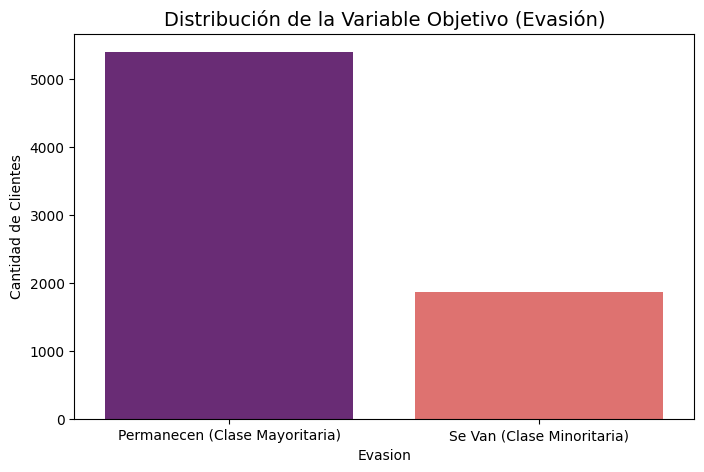

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular frecuencias
conteo = df_final['Evasion'].value_counts()
proporcion = df_final['Evasion'].value_counts(normalize=True) * 100

print(f"--- Análisis de Clases ---")
print(f"Permanecen (0): {conteo[0]} clientes ({proporcion[0]:.2f}%)")
print(f"Se van (1):      {conteo[1]} clientes ({proporcion[1]:.2f}%)")

# 2. Visualización
plt.figure(figsize=(8, 5))
sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index, palette='magma', legend=False)
plt.title('Distribución de la Variable Objetivo (Evasión)', fontsize=14)
plt.xticks([0, 1], ['Permanecen (Clase Mayoritaria)', 'Se Van (Clase Minoritaria)'])
plt.ylabel('Cantidad de Clientes')
plt.show()

## Balanceo de Clases

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

### Implementación del Balanceo

In [12]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Separar características (X) y objetivo (y)
X = df_final.drop('Evasion', axis=1)
y = df_final['Evasion']

# 2. Dividir en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Antes de SMOTE (entrenamiento): {y_train.value_counts().to_dict()}")
print(f"Después de SMOTE (entrenamiento): {y_train_bal.value_counts().to_dict()}")

Antes de SMOTE (entrenamiento): {0: 3778, 1: 1308}
Después de SMOTE (entrenamiento): {0: 3778, 1: 3778}


## Normalización o Estandarización (si es necesario)

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

### Implementación con StandardScaler

Utilizaremos StandardScaler, que transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Esto mantiene la forma de la distribución pero nivela el "terreno de juego".

Importante: Debemos estandarizar después de haber aplicado SMOTE (sobre los datos ya balanceados) para asegurar que el escalado se aplique a todo el conjunto de entrenamiento de forma uniforme.

In [13]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializar el escalador
scaler = StandardScaler()

# 2. Ajustar y transformar los datos de entrenamiento (ya balanceados con SMOTE)
X_train_scaled = scaler.fit_transform(X_train_bal)

# 3. Transformar los datos de prueba (usando el ajuste de entrenamiento para evitar fuga de datos)
X_test_scaled = scaler.transform(X_test)

print("Ejemplo de datos escalados (primeras 2 filas):")
print(X_train_scaled[:2])

Ejemplo de datos escalados (primeras 2 filas):
[[-0.40039906  1.85338666  1.39186998  2.59163783 -0.86947352  1.29849923
   1.94636576  0.34314935 -0.29156237  1.29263624  0.98528559 -0.44308779
  -0.44308779  1.94092566 -0.44308779  1.66900304 -0.44308779  1.63121204
  -0.44308779  1.97006014 -0.44308779 -0.72940776 -0.44308779  1.33838778
  -0.41496965  2.25471415 -1.21047629  2.39340888 -0.73708931 -0.46661294]
 [-0.40039906 -0.93679858 -1.68194979 -0.88291002 -0.86947352 -0.77011983
  -0.51377805  0.34314935 -0.29156237 -0.77361285 -1.01493416  2.25688909
   2.25688909 -0.51521808  2.25688909 -0.59916008  2.25688909 -0.61304109
   2.25688909 -0.50759872  2.25688909 -0.72940776  2.25688909 -0.74716761
  -0.41496965 -0.4435152  -1.21047629  2.39340888 -0.73708931 -0.46661294]]


## 🎯 Correlación y Selección de Variables

### Análisis de Correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

### Visualización del Mapa de Calor (Heatmap)
Ejecuta este código para generar una matriz completa. Usaremos un filtro para ver solo las variables que más afectan a la Evasion.

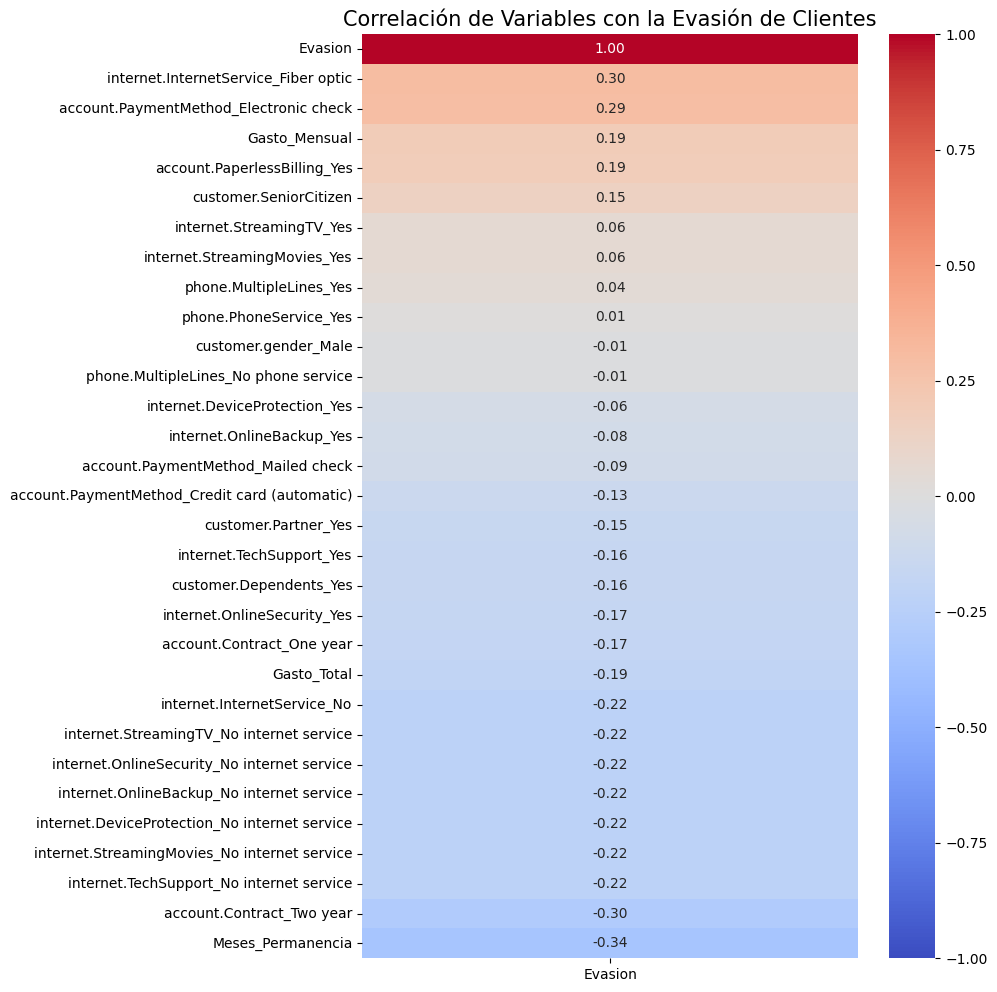

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular la matriz de correlación
corr_matrix = df_final.corr()

# 2. Filtrar las correlaciones específicas con la variable objetivo 'Evasion'
# Ordenamos de mayor a menor para identificar los factores de riesgo
evasion_corr = corr_matrix[['Evasion']].sort_values(by='Evasion', ascending=False)

# 3. Graficar
plt.figure(figsize=(8, 12))
sns.heatmap(evasion_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlación de Variables con la Evasión de Clientes', fontsize=15)
plt.show()

## Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

### Tiempo de Contrato × Cancelación (Análisis de Barreras)

Queremos ver si la duración del contrato actúa realmente como un "ancla" de lealtad. Usaremos un gráfico de barras apiladas al 100% para comparar proporciones, ya que los volúmenes de clientes en cada contrato son distintos.

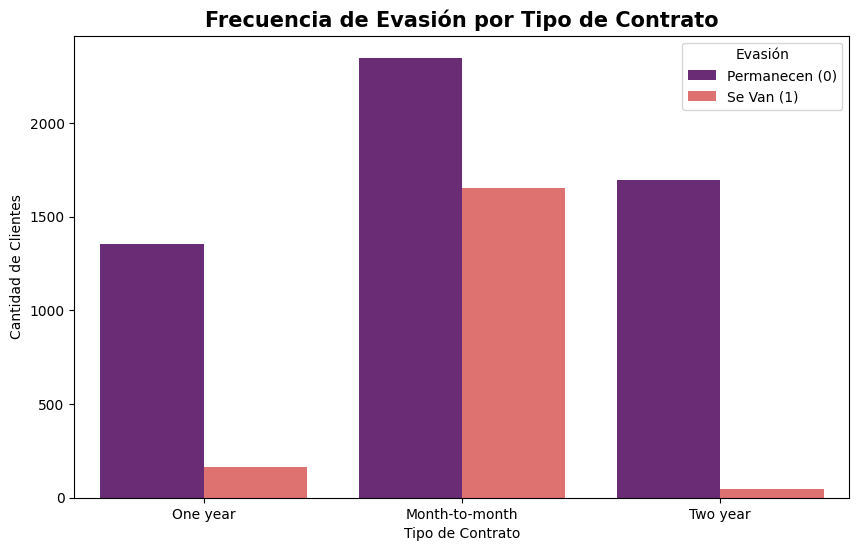

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Relación Contrato vs Evasión
plt.figure(figsize=(10, 6))
# Usamos el dataframe original antes del encoding para tener las etiquetas de texto
sns.countplot(data=df_ml, x='account.Contract', hue='Evasion', palette='magma')

plt.title('Frecuencia de Evasión por Tipo de Contrato', fontsize=15, fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Evasión', labels=['Permanecen (0)', 'Se Van (1)'])
plt.show()

### . Gasto Total × Cancelación (Análisis de Valor de Vida)

Aquí usaremos un Boxplot para ver la distribución del dinero y un KDE Plot (curva de densidad) para ver en qué punto exacto del gasto se "rompe" la relación con el cliente.

/tmp/ipykernel_151/3665756169.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Permanecen (0)', 'Se Van (1)'])


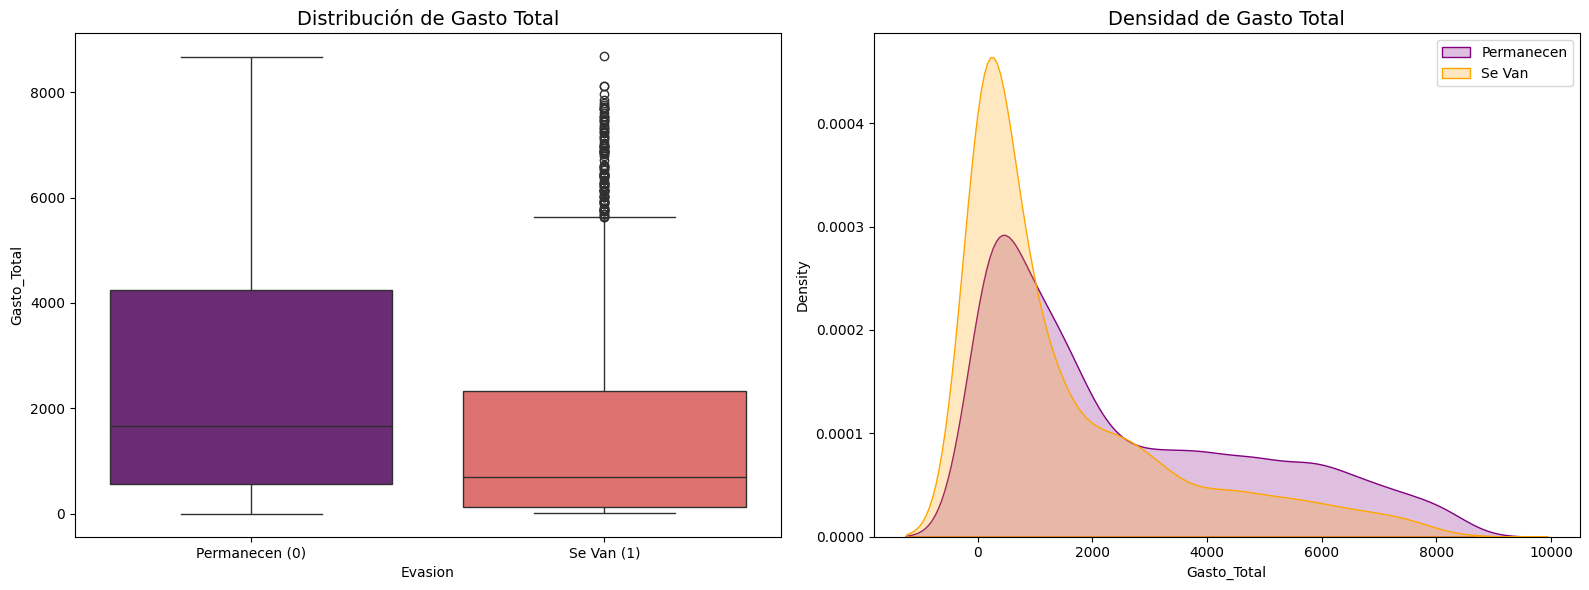

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot para ver medianas y valores atípicos
sns.boxplot(data=df_ml, x='Evasion', y='Gasto_Total', palette='magma', ax=axes[0], hue='Evasion', legend=False)
axes[0].set_title('Distribución de Gasto Total', fontsize=14)
axes[0].set_xticklabels(['Permanecen (0)', 'Se Van (1)'])

# KDE Plot para ver la concentración del gasto
sns.kdeplot(data=df_ml[df_ml['Evasion'] == 0]['Gasto_Total'], label='Permanecen', fill=True, ax=axes[1], color='purple')
sns.kdeplot(data=df_ml[df_ml['Evasion'] == 1]['Gasto_Total'], label='Se Van', fill=True, ax=axes[1], color='orange')
axes[1].set_title('Densidad de Gasto Total', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 🤖 Modelado Predictivo

### Separación de Datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

### ⚙️ Implementación de la Separación de Datos
Usaremos train_test_split de Scikit-Learn. Un detalle vital aquí es el parámetro stratify: esto asegura que la proporción de clientes que se van (26%) se mantenga idéntica tanto en el grupo de entrenamiento como en el de prueba.

In [17]:
from sklearn.model_selection import train_test_split

# 1. Definimos X (características) y y (objetivo)
# Asegúrate de usar el DataFrame 'df_final' que ya tiene el encoding y no tiene IDs
X = df_final.drop('Evasion', axis=1)
y = df_final['Evasion']

# 2. División de datos (70% entrenamiento, 30% prueba)
# random_state=42: garantiza que los resultados sean replicables
# stratify=y: mantiene la proporción de Churn en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Muestras de Entrenamiento: {X_train.shape[0]}")
print(f"Muestras de Prueba: {X_test.shape[0]}")
print(f"\nProporción de Evasión en Entrenamiento: {y_train.mean():.2%}")
print(f"Proporción de Evasión en Prueba: {y_test.mean():.2%}")

Muestras de Entrenamiento: 5086
Muestras de Prueba: 2181

Proporción de Evasión en Entrenamiento: 25.72%
Proporción de Evasión en Prueba: 25.72%


## Creación de Modelos

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

### Modelo 1: Regresión Logística (Requiere Normalización)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Creamos un Pipeline para asegurar que el escalado solo se base en los datos de entrenamiento
pipeline_log = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, class_weight='balanced'))
])

# Entrenamos (usando los datos de entrenamiento originales X_train, y_train)
pipeline_log.fit(X_train, y_train)

print("✅ Modelo de Regresión Logística entrenado con normalización.")

✅ Modelo de Regresión Logística entrenado con normalización.


### Modelo 2: Random Forest (No requiere Normalización)

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar el modelo
# Usamos class_weight='balanced' para ayudar con el desbalance detectado anteriormente
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Entrenar el modelo con los datos originales (sin escalar)
model_rf.fit(X_train, y_train)

print("✅ Modelo de Random Forest entrenado (sin necesidad de normalización).")

✅ Modelo de Random Forest entrenado (sin necesidad de normalización).


## Evaluación de los Modelos

Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

### Ejecución de Evaluación y Métricas
Usaremos el conjunto de prueba (X_test), que el modelo nunca ha visto, para garantizar que los resultados sean honestos.

--- Métricas: Regresión Logística ---
Accuracy:  0.7423
Precision: 0.4994
Recall:    0.8039
F1-Score:  0.6161


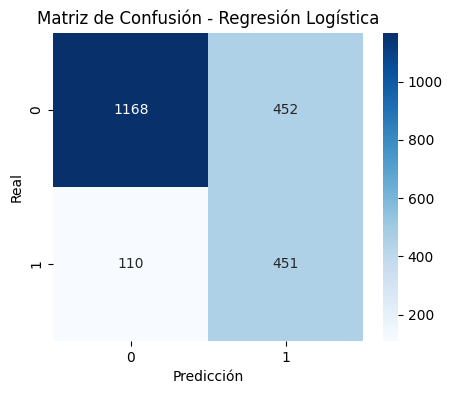

--- Métricas: Random Forest ---
Accuracy:  0.7886
Precision: 0.6147
Recall:    0.4777
F1-Score:  0.5376


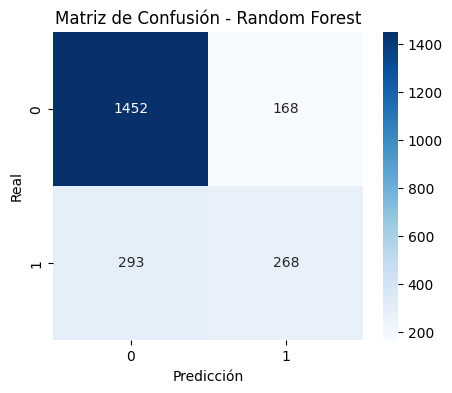

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluar_modelo(modelo, X_test, y_test, nombre):
    y_pred = modelo.predict(X_test)

    print(f"--- Métricas: {nombre} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.show()

# Evaluamos ambos
evaluar_modelo(pipeline_log, X_test, y_test, "Regresión Logística")
evaluar_modelo(model_rf, X_test, y_test, "Random Forest")

## 📋 Interpretación y Conclusiones

### Análisis de la Importancia de las Variables

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

### Coeficientes en Regresión Logística
En este modelo, cada variable recibe un coeficiente.

Coeficiente Positivo: Aumenta la probabilidad de que el cliente se vaya (ej. Contrato mes a mes).

Coeficiente Negativo: Actúa como un factor de retención (ej. Larga permanencia).

/tmp/ipykernel_151/1069175914.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.concat([df_coefs.head(5), df_coefs.tail(5)]), x='Coeficiente', y='Variable', palette='coolwarm')


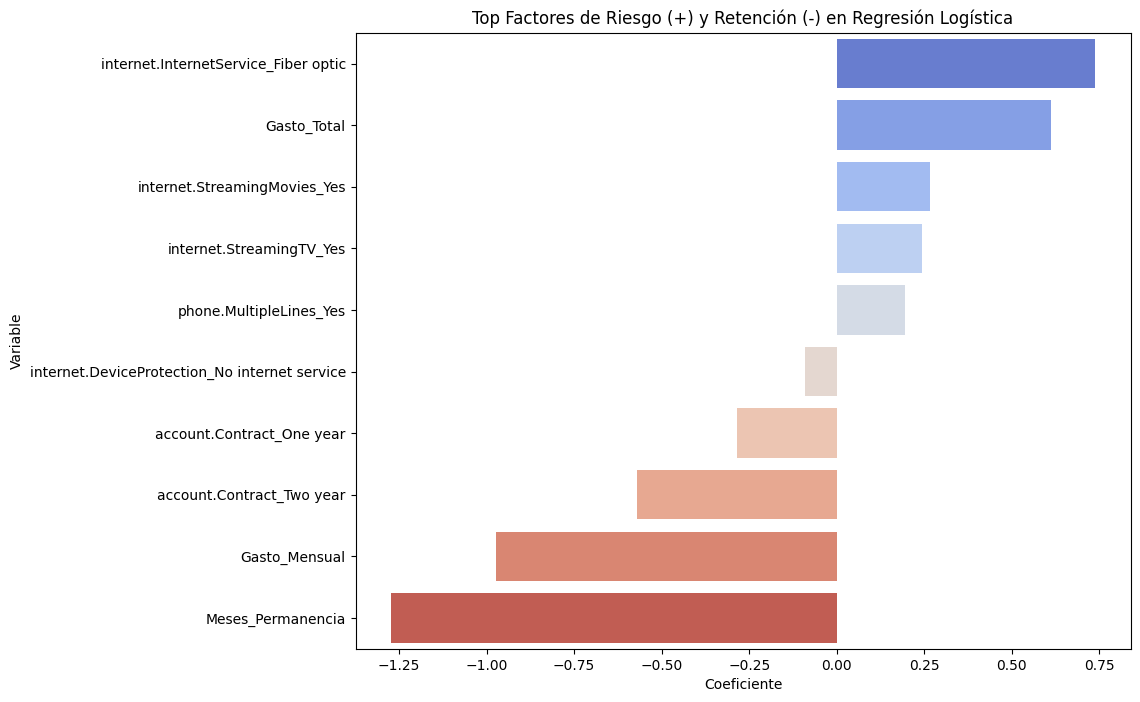

In [21]:
import numpy as np

# Extraer coeficientes del pipeline (accediendo al paso 'clf')
importancias_log = pipeline_log.named_steps['clf'].coef_[0]
nombres_vars = X_train.columns

# Crear un DataFrame para visualizar
df_coefs = pd.DataFrame({'Variable': nombres_vars, 'Coeficiente': importancias_log})
df_coefs = df_coefs.sort_values(by='Coeficiente', ascending=False)

# Graficar los top 10 factores de riesgo y retención
plt.figure(figsize=(10, 8))
sns.barplot(data=pd.concat([df_coefs.head(5), df_coefs.tail(5)]), x='Coeficiente', y='Variable', palette='coolwarm')
plt.title('Top Factores de Riesgo (+) y Retención (-) en Regresión Logística')
plt.show()

### Importancia de Variables en Random Forest
El Random Forest mide qué tanto ayuda cada variable a "limpiar" la incertidumbre en los árboles (Gini Importance). Es excelente para detectar relaciones que no son necesariamente una línea recta.

/tmp/ipykernel_151/3513679747.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia_rf.head(10), x='Importancia', y='Variable', palette='viridis')


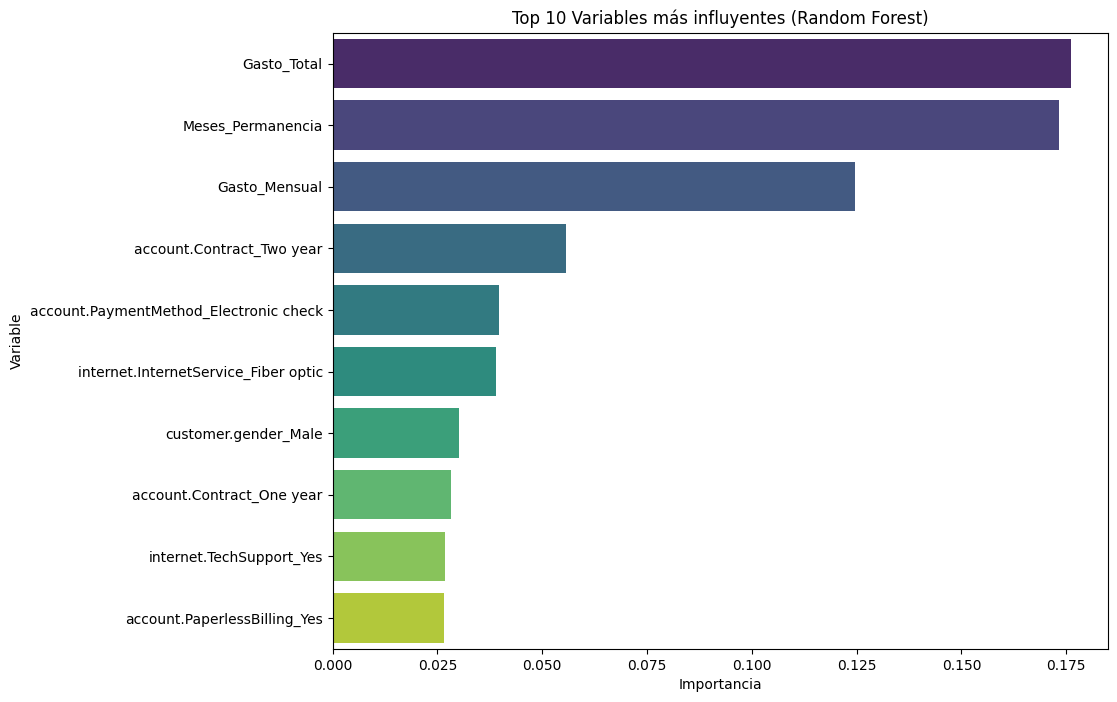

In [22]:
# Extraer importancia
importancias_rf = model_rf.feature_importances_

# Crear DataFrame
df_importancia_rf = pd.DataFrame({'Variable': nombres_vars, 'Importancia': importancias_rf})
df_importancia_rf = df_importancia_rf.sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 8))
sns.barplot(data=df_importancia_rf.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title('Top 10 Variables más influyentes (Random Forest)')
plt.show()

### Síntesis de Hallazgos para Telecom X
Comparando ambos modelos, podemos llegar a conclusiones potentes para la gerencia:

El Factor Tiempo: Tanto el coeficiente negativo en Logística como la alta importancia en RF para Meses_Permanencia confirman que la antigüedad es el mejor escudo contra la evasión.

El "Cáncer" del Negocio: El contrato Month-to-month aparecerá probablemente como la variable con el coeficiente positivo más alto. Es un predictor casi infalible de fuga.

Servicios Críticos: Si la Fiber optic aparece con alta importancia pero con coeficiente positivo, significa que el servicio de fibra, aunque es el más caro, está fallando en retener a la gente (posiblemente por precio o estabilidad).

🏁 Conclusión Estratégica

"El modelo Random Forest es preferible para la detección precisa, pero la Regresión Logística nos da la hoja de ruta estratégica: debemos migrar a los clientes de fibra óptica hacia contratos de un año y automatizar sus pagos para reducir los coeficientes de riesgo detectados".